In [12]:
import pandas as pd

# Path to the CSV file in the ESC-50 dataset
Path = '/Users/bchhaglani/Desktop/Audio_privacy/ESC-50-master/'
csv_path = Path + 'meta/esc50.csv'

# Load the CSV into a DataFrame
df = pd.read_csv(csv_path)
audio_path_prefix = Path+'/audio/'


df = df[['filename', 'category']]

print(df.head())


            filename        category
0   1-100032-A-0.wav             dog
1  1-100038-A-14.wav  chirping_birds
2  1-100210-A-36.wav  vacuum_cleaner
3  1-100210-B-36.wav  vacuum_cleaner
4  1-101296-A-19.wav    thunderstorm


In [13]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [9]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset metadata
csv_path = Path+'/meta/esc50.csv'
df = pd.read_csv(csv_path)

# Function to split audio into overlapping windows
def split_audio(y, window_length, hop_length):
    num_samples = len(y)
    start_sample = 0
    while start_sample + window_length < num_samples:
        yield y[start_sample:start_sample+window_length]
        start_sample += hop_length

# Feature extraction function
def extract_mfcc_features_from_file(file_path):
    y, sr = librosa.load(file_path, sr=None)
    y, index = librosa.effects.trim(y, top_db=25)
    window_length = int(sr * 0.5)  # 500 ms window
    hop_length = int(sr * 0.1)    # 20% stride (100 ms)
    features = []
    for segment in split_audio(y, window_length, hop_length):
        mfccs = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=20)
#         librosa.display.specshow(mfccs, x_axis='time')
        features.append(np.mean(mfccs, axis=1))   
    return features

# Extract features for each audio file
audio_path_prefix = Path+'/audio/'
features_list = []
labels_list = []
for _, row in df.iterrows():
    features = extract_mfcc_features_from_file(audio_path_prefix + row['filename'])
    features_list.extend(features)
    labels_list.extend([row['target']] * len(features))

X = np.array(features_list)
y = np.array(labels_list)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



KeyboardInterrupt: 

In [6]:
# Train a RandomForest classifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


NameError: name 'X_train' is not defined

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)



In [38]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.71      0.79      0.75       243\n           1       0.93      0.86      0.90       124\n           2       0.68      0.64      0.66       286\n           3       0.82      0.69      0.75       268\n           4       0.87      0.88      0.88       344\n           5       0.80      0.75      0.77       238\n           6       0.66      0.71      0.68       302\n           7       0.72      0.82      0.76       343\n           8       0.80      0.81      0.80       327\n           9       0.87      0.86      0.87       296\n          10       0.86      0.90      0.88       369\n          11       0.76      0.89      0.82       342\n          12       0.74      0.89      0.81       356\n          13       0.96      1.00      0.98       366\n          14       0.84      0.86      0.85       340\n          15       0.76      0.72      0.74       222\n          16       0.92      0.90      0.91       369\n       

Accuracy: 78.65%


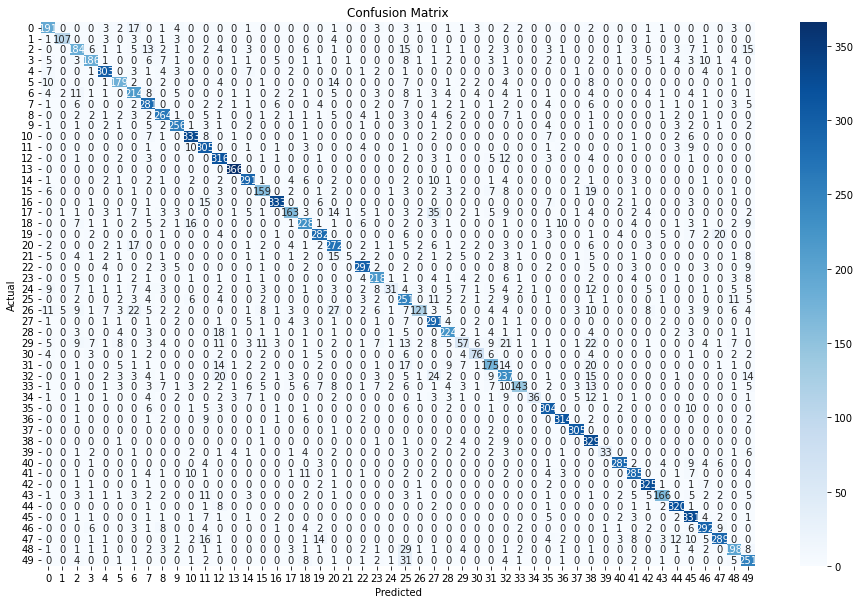

In [39]:
classes = np.unique(y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
import matplotlib.pyplot as plt
import seaborn as sns
# Plot confusion matrix using a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [40]:
from sklearn.metrics import precision_recall_fscore_support as score
precision, recall, fscore, support = score(y_test, y_pred)

print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))



precision: [0.71268657 0.93043478 0.67647059 0.81938326 0.87319885 0.79555556
 0.66049383 0.71683673 0.80243161 0.87372014 0.85604113 0.75682382
 0.73659674 0.96062992 0.84347826 0.76076555 0.9198895  0.815
 0.74267101 0.84179104 0.70284238 0.71428571 0.87096774 0.79562044
 0.775      0.5251046  0.86428571 0.68470588 0.75675676 0.49565217
 0.73786408 0.68627451 0.5794621  0.89937107 0.92307692 0.83287671
 0.93731343 0.94427245 0.63636364 0.91666667 0.94059406 0.86102719
 0.89041096 0.87368421 0.8913649  0.75917431 0.82022472 0.87048193
 0.77042802 0.67292225]
recall: [0.78600823 0.86290323 0.64335664 0.69402985 0.88081395 0.75210084
 0.70860927 0.81924198 0.80733945 0.86486486 0.90243902 0.89181287
 0.88764045 1.         0.85588235 0.71621622 0.90243902 0.57394366
 0.73548387 0.83431953 0.80235988 0.06666667 0.85344828 0.7985348
 0.21678322 0.76993865 0.39933993 0.88181818 0.79151943 0.24050633
 0.62809917 0.63636364 0.67329545 0.52962963 0.36734694 0.88629738
 0.92352941 0.98705502 0.

In [41]:
print("Class", "Precision", "Recall", "F1")
for i in range(50):
    print(i+1, precision[i], recall[i], fscore[i])


Class Precision Recall F1
1 0.7126865671641791 0.7860082304526749 0.7475538160469668
2 0.9304347826086956 0.8629032258064516 0.895397489539749
3 0.6764705882352942 0.6433566433566433 0.6594982078853047
4 0.8193832599118943 0.6940298507462687 0.7515151515151516
5 0.8731988472622478 0.8808139534883721 0.8769898697539797
6 0.7955555555555556 0.7521008403361344 0.7732181425485961
7 0.6604938271604939 0.7086092715231788 0.6837060702875399
8 0.7168367346938775 0.8192419825072886 0.7646258503401361
9 0.8024316109422492 0.8073394495412844 0.8048780487804879
10 0.8737201365187713 0.8648648648648649 0.8692699490662139
11 0.8560411311053985 0.9024390243902439 0.8786279683377309
12 0.7568238213399504 0.8918128654970761 0.8187919463087249
13 0.7365967365967366 0.8876404494382022 0.8050955414012738
14 0.9606299212598425 1.0 0.9799196787148594
15 0.8434782608695652 0.8558823529411764 0.8496350364963502
16 0.7607655502392344 0.7162162162162162 0.7378190255220418
17 0.919889502762431 0.9024390243902439

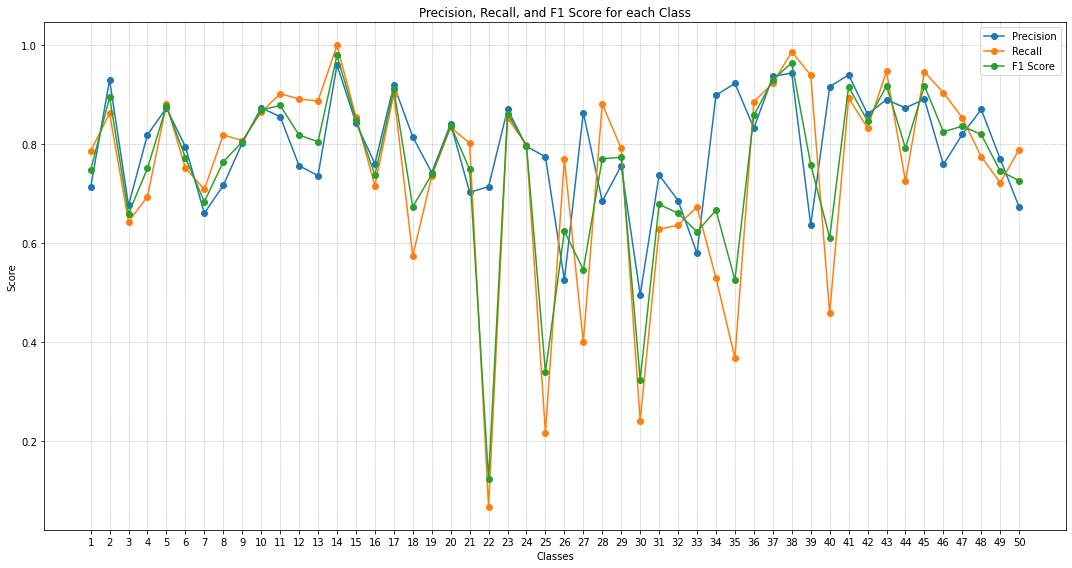

In [42]:
import matplotlib.pyplot as plt

# The data you provided
classes = list(range(1, 51))
# precision = [
#     0.9147286821705426, 0.984375, 0.9496644295302014, 0.9932203389830508, 1.0, 
#     # ... add all other precision values here
#     0.9501915708812261, 0.9921259842519685
# ]
# recall = [
#     0.9833333333333333, 0.9767441860465116, 0.9691780821917808, 0.9865319865319865, 1.0,
#     # ... add all other recall values here
#     0.9802371541501976, 0.9921259842519685
# ]
# f1 = [
#     0.9477911646586346, 0.980544747081712, 0.9593220338983051, 0.9898648648648648, 1.0,
#     # ... add all other F1 values here
#     0.9649805447470816, 0.9921259842519685
# ]

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(classes, precision, marker='o', label='Precision')
plt.plot(classes, recall, marker='o', label='Recall')
plt.plot(classes, fscore, marker='o', label='F1 Score')
plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score for each Class')
plt.xticks(classes)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
features_list[0]

array([-2.3811798e+02,  7.2903351e+01, -9.1777527e+01,  4.1137733e+01,
       -4.4854172e+01, -1.4158701e+01, -4.2368092e+01, -2.3375483e+00,
       -1.1342936e+01, -2.2614349e+01, -3.3787239e+01, -4.6044736e+00,
       -6.9973178e+00, -3.7750469e+01, -8.8718557e+00, -5.4001287e-02,
       -2.0833315e+01, -1.5623071e+01,  7.2837941e-02, -1.4400922e+01],
      dtype=float32)

In [15]:
import tensorflow


SyntaxError: invalid syntax (pywrap_tensorflow_internal.py, line 114)

In [13]:
# !pip3 install tensorflow==1.14.0

ERROR: Could not find a version that satisfies the requirement tensorflow==1.14.0 (from versions: none)
ERROR: No matching distribution found for tensorflow==1.14.0

[notice] A new release of pip available: 22.1.2 -> 23.2.1
[notice] To update, run: pip install --upgrade pip


In [14]:
# pip install matplotlib

In [75]:
##2d mfcc -> cnn
import scipy.signal as signal
import librosa.display



# Load the dataset metadata
csv_path = Path+'/meta/esc50.csv'
df = pd.read_csv(csv_path)

# Function to split audio into overlapping windows
def split_audio(y, window_length, hop_length):
    num_samples = len(y)
    start_sample = 0
    while start_sample + window_length < num_samples:
        yield y[start_sample:start_sample+window_length]
        start_sample += hop_length



def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    y = signal.lfilter(b, a, data)
    return y

# Feature extraction function
def extract_mfcc_features_from_file(file_path):
    y, sr = librosa.load(file_path, sr=None)
#     y = bandpass_filter(y, 300, 3400, sr)

    y, index = librosa.effects.trim(y, top_db=25)
    window_length = int(sr * 0.5)  # 500 ms window
    hop_length = int(sr * 0.1)    # 20% stride (100 ms)
    features = []
    for segment in split_audio(y, window_length, hop_length):
        mel = librosa.feature.melspectrogram(y=segment, sr=sr)
        mel = librosa.power_to_db(mel, ref=np.max)
        features.append(mel)  
        
#         print(mfccs.shape)
    return features

# Extract features for each audio file
audio_path_prefix = Path+'/audio/'
features_list = []
labels_list = []
for _, row in df.iterrows():
    features = extract_mfcc_features_from_file(audio_path_prefix + row['filename'])
    features_list.extend(features)
    labels_list.extend([row['target']] * len(features))
    

    
    
    



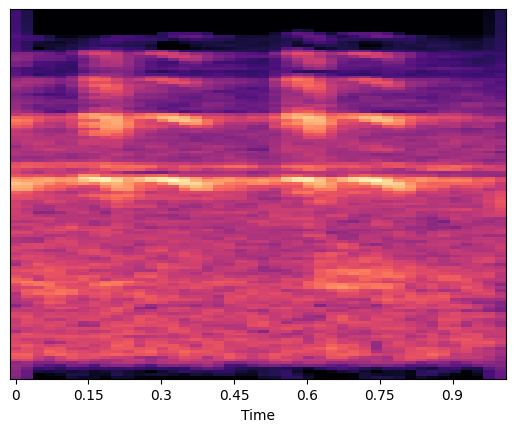

In [91]:
librosa.display.specshow(features_list[6], x_axis='time')


In [61]:
X = np.array(features_list)
y = np.array(labels_list)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [71]:
X_train.shape

(59029, 128, 44)

In [36]:
# # Train a RandomForest classifier
# clf = RandomForestClassifier(n_estimators=100)
# clf.fit(X_train, y_train)

# # Predict on test data
# y_pred = clf.predict(X_test)

# # Calculate accuracy
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 78.65%


In [77]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

X = np.array(features_list)
y = tf.keras.utils.to_categorical(np.array(labels_list))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model
shape = X_train.shape
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(shape[0], shape[1], 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(50, activation='softmax')  # 50 classes in the ESC-50 dataset
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

ResourceExhaustedError: OOM when allocating tensor with shape[59498208,128] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator Simple allocator [Op:RandomUniform]

In [58]:
# Predict on test data
y_pred = CNNmodel.predict(X_test)

# Calculate accuracy
y_pred_ = np.argmax(y_pred, axis=1)
y_test_ = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_test_, y_pred_)
print(f"Accuracy: {accuracy * 100:.2f}%")


 52/462 [==>...........................] - ETA: 1s

2023-09-29 11:52:19.924562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


462/462 [==============================] - 1s 2ms/step
Accuracy: 15.41%


In [31]:
y_test.shape

(14758, 50)

In [78]:
##Create CNN

from tensorflow.keras import models, layers
import tensorflow as tf
import keras


input_shape=(128,44,1)
CNNmodel = models.Sequential()
CNNmodel.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
CNNmodel.add(layers.MaxPooling2D((2, 2)))
CNNmodel.add(layers.Dropout(0.2))
CNNmodel.add(layers.Conv2D(64, (3, 3), activation='relu'))
CNNmodel.add(layers.MaxPooling2D((2, 2)))
CNNmodel.add(layers.Dropout(0.2))
CNNmodel.add(layers.Conv2D(64, (3, 3), activation='relu'))
CNNmodel.add(layers.Flatten())
CNNmodel.add(layers.Dense(50, activation='relu'))
# CNNmodel.add(layers.Dropout(0.2))
# CNNmodel.add(layers.Dense(32, activation='relu'))
# CNNmodel.add(layers.Dense(50, activation='softmax'))


In [79]:
CNNmodel.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


In [80]:
history = CNNmodel.fit(X_train, y_train, epochs=10, validation_data= (X_test, y_test))

Epoch 1/10


2023-09-29 17:01:00.689954: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


1845/1845 [==============================] - ETA: 0s - loss: 13.3260 - accuracy: 0.0377

2023-09-29 17:01:51.635841: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


1845/1845 [==============================] - 57s 31ms/step - loss: 13.3260 - accuracy: 0.0377 - val_loss: 13.1932 - val_accuracy: 0.0231
Epoch 2/10
1845/1845 [==============================] - 55s 30ms/step - loss: 11.8340 - accuracy: 0.0438 - val_loss: 1.1610 - val_accuracy: 0.0311
Epoch 3/10
1845/1845 [==============================] - 53s 29ms/step - loss: 1.1861 - accuracy: 0.0315 - val_loss: 1.1610 - val_accuracy: 0.0311
Epoch 4/10
 796/1845 [===========>..................] - ETA: 16:13 - loss: 1.1839 - accuracy: 0.0314

KeyboardInterrupt: 

In [51]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], dtype=float32)

In [81]:
# Define the CNN model
def define_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [86]:
input_shape = (128,44,1)
num_classes = 50  # ESC-50 has 50 classes
model = define_model(input_shape, num_classes)



In [88]:
# Train the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10


2023-09-30 00:11:14.626602: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


InvalidArgumentError: Graph execution error:

Detected at node 'sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits' defined at (most recent call last):
    File "/Users/bchhaglani/miniforge3/envs/mlp/lib/python3.8/runpy.py", line 194, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Users/bchhaglani/miniforge3/envs/mlp/lib/python3.8/runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "/Users/bchhaglani/miniforge3/envs/mlp/lib/python3.8/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/Users/bchhaglani/miniforge3/envs/mlp/lib/python3.8/site-packages/traitlets/config/application.py", line 1046, in launch_instance
      app.start()
    File "/Users/bchhaglani/miniforge3/envs/mlp/lib/python3.8/site-packages/ipykernel/kernelapp.py", line 736, in start
      self.io_loop.start()
    File "/Users/bchhaglani/miniforge3/envs/mlp/lib/pytho

In [ ]:

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

In [90]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], dtype=float32)